In [1]:
%load_ext autoreload
%autoreload 2

# Part 4: XOR Problem
Goal of this notebook is testing all framework `core` has built with XOR problem
* **Inpput (X):** `[0,0], [0,1], [1,0], [1,1]`
* **Output (Y):** `[0], [1], [1], [0]`

## Import files and libraries

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from core.activation import Sigmoid,ReLU
from core.layer import Dense
from core.network import Network
from core.loss import bce,bce_prime

## 1.Prepare data

In [5]:
X_train=np.array([[0,0], [0,1], [1,0], [1,1]])
y_train=np.array([[0], [1], [1], [0]])

In [15]:
X_train.shape

(4, 2)

## 2. Build and fit neuron-network
To solve XOR problem, we will build MLP network with architecture:
* **Input Layer:** 2 neurons
* **Hidden Layer:** 3 neurons with `Sigmoid` activation. Why 3 neurons? Because 3 neurons create 3 lines, provide enough redundancy to the boundaries without fear of local minimum
* **Output Layer:** 1 neuron with `Sigmoid` function
* **Loss Function:** Binary Cross-entropy (BCE)

In [18]:
net=Network()
net.add(Dense(2,3))
net.add(Sigmoid())
net.add(Dense(3,1))
net.add(Sigmoid())

net.compile(bce,bce_prime)

In [19]:
history=net.fit(X_train,y_train,epochs=5000,learning_rate=0.5,verbose=True)

Epoch  100/5000 | Loss: 0.690943
Epoch  200/5000 | Loss: 0.688164
Epoch  300/5000 | Loss: 0.681139
Epoch  400/5000 | Loss: 0.662945
Epoch  500/5000 | Loss: 0.621043
Epoch  600/5000 | Loss: 0.554463
Epoch  700/5000 | Loss: 0.467977
Epoch  800/5000 | Loss: 0.324428
Epoch  900/5000 | Loss: 0.184970
Epoch 1000/5000 | Loss: 0.112336
Epoch 1100/5000 | Loss: 0.076844
Epoch 1200/5000 | Loss: 0.057288
Epoch 1300/5000 | Loss: 0.045246
Epoch 1400/5000 | Loss: 0.037194
Epoch 1500/5000 | Loss: 0.031474
Epoch 1600/5000 | Loss: 0.027220
Epoch 1700/5000 | Loss: 0.023943
Epoch 1800/5000 | Loss: 0.021346
Epoch 1900/5000 | Loss: 0.019241
Epoch 2000/5000 | Loss: 0.017502
Epoch 2100/5000 | Loss: 0.016043
Epoch 2200/5000 | Loss: 0.014802
Epoch 2300/5000 | Loss: 0.013735
Epoch 2400/5000 | Loss: 0.012807
Epoch 2500/5000 | Loss: 0.011994
Epoch 2600/5000 | Loss: 0.011275
Epoch 2700/5000 | Loss: 0.010636
Epoch 2800/5000 | Loss: 0.010064
Epoch 2900/5000 | Loss: 0.009549
Epoch 3000/5000 | Loss: 0.009082
Epoch 3100

## 3. Predict 

In [20]:
predictions=net.predict(X_train)
for i in range(len(X_train)):
    print(f'Input: {X_train[i]} -> Target: {y_train[i]} | AI prediction: {predictions[i]}')

Input: [0 0] -> Target: [0] | AI prediction: [0.00518647]
Input: [0 1] -> Target: [1] | AI prediction: [0.99555699]
Input: [1 0] -> Target: [1] | AI prediction: [0.99593049]
Input: [1 1] -> Target: [0] | AI prediction: [0.00448055]


**Visualize Decision Boundary**

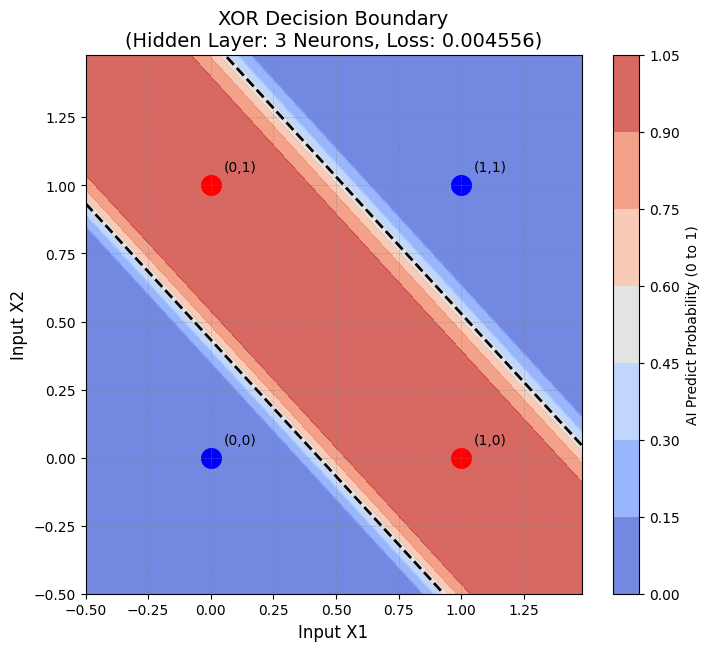

In [32]:
h = 0.02 
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_input = np.c_[xx.ravel(), yy.ravel()]
grid_predictions = net.predict(grid_input)
grid_predictions = grid_predictions.reshape(xx.shape)
plt.figure(figsize=(8, 7))
contour = plt.contourf(xx, yy, grid_predictions, cmap='coolwarm', alpha=0.8)
plt.colorbar(contour, label="AI Predict Probability (0 to 1)")
plt.contour(xx, yy, grid_predictions,levels=[0.5], colors='black', linewidths=2, linestyles='--')
for i in range(len(X_train)):
    point_color = 'red' if y_train[i] == 1 else 'blue'
    plt.scatter(X_train[i, 0], X_train[i, 1], color=point_color, s=200)
    plt.text(X_train[i, 0]+0.05, X_train[i, 1]+0.05, f"({X_train[i,0]},{X_train[i,1]})", fontsize=10, zorder=11)

plt.title(f"XOR Decision Boundary\n(Hidden Layer: 3 Neurons, Loss: {history[-1]:.6f})", fontsize=14)
plt.xlabel("Input X1", fontsize=12)
plt.ylabel("Input X2", fontsize=12)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.show()

## 4. Visualizing Loss curve

C:\Users\OS\AppData\Local\Temp\ipykernel_32404\305199255.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


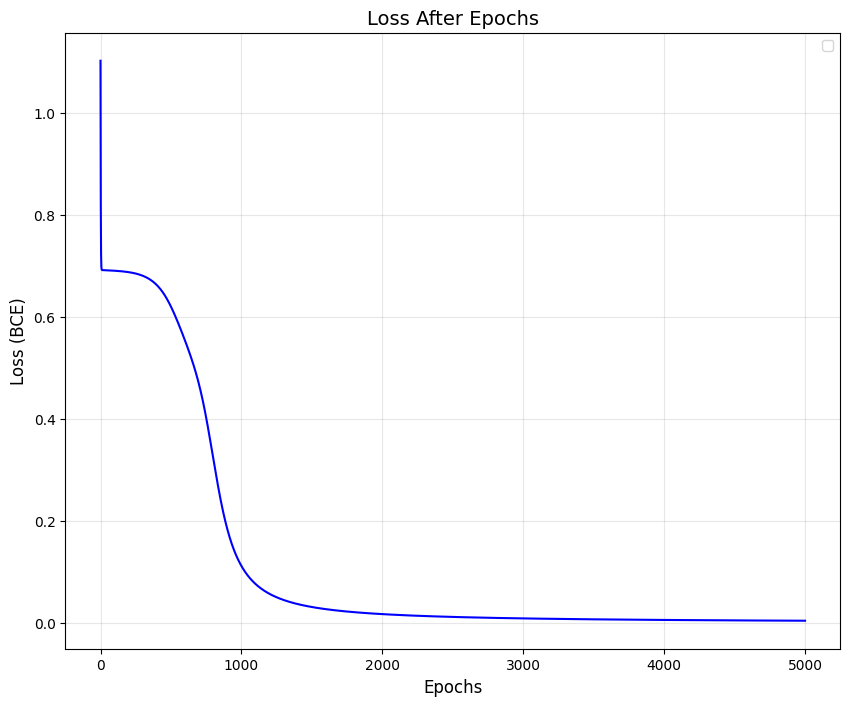

In [22]:
plt.figure(figsize=(10,8))
plt.plot(history,color='blue')
plt.title('Loss After Epochs',fontsize=14)
plt.xlabel('Epochs',fontsize=12)
plt.ylabel('Loss (BCE)',fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Conclusion and Evaluation
* The decline of loss graph prove that the weight matrix $W$, bias matrix $b$, matrix transpose and **Backpropagation** algorithm are correct
* The neuron network has built from cratch is be able to find nonlinear boundaries to solve complex problems 